<a href="https://colab.research.google.com/github/k2herat/MMK/blob/second_task/Almetov_MMK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
from scipy.stats import uniform, randint

wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='target')

print("Структура данных:")
display(X.head())
print("\nТипы признаков и пропуски:")
print(X.info())

Структура данных:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Типы признаков и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 no

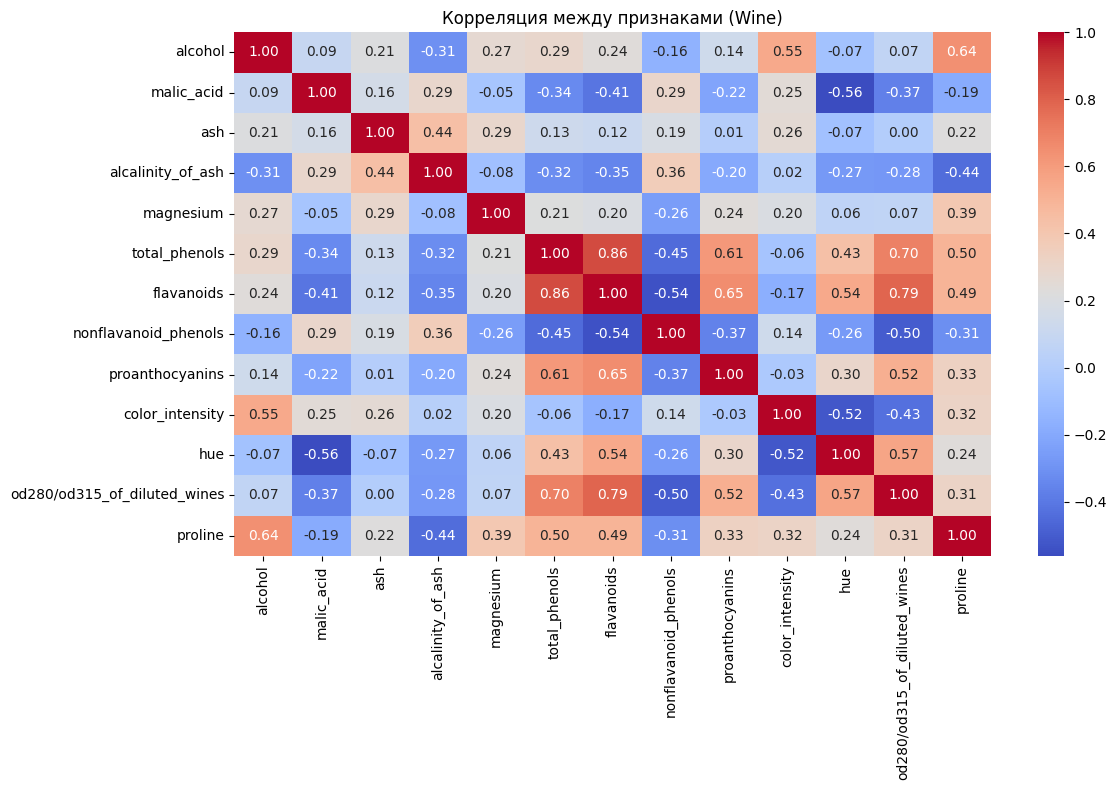

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляция между признаками (Wine)")
plt.tight_layout()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

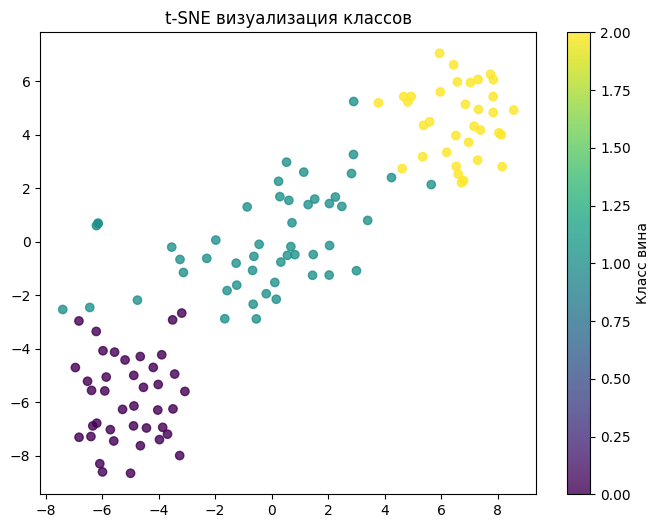

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.8)
plt.title("t-SNE визуализация классов")
plt.colorbar(scatter, label='Класс вина')
plt.show()

In [ ]:
models = {
    "Логистическая регрессия": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Случайный лес": RandomForestClassifier(random_state=42),
    "Градиентный бустинг": GradientBoostingClassifier(random_state=42),
    "Наивный байес": GaussianNB(),
    "KNN": KNeighborsClassifier()
}
param_distributions = {
    "SVM": {
        'C': uniform(0.1, 10),
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    },
    "Случайный лес": {
        'n_estimators': randint(50, 200),
        'max_depth': randint(3, 15)
    }
}

results = []
n_bootstraps = 100

for name, model in models.items():
    start_time = time.time()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc_full = accuracy_score(y_test, y_pred)
    train_time = time.time() - start_time


    conf_matrix = confusion_matrix(y_test, y_pred)


    boot_scores = []
    for _ in range(n_bootstraps):
        X_boot, y_boot = resample(X_train_scaled, y_train)
        model.fit(X_boot, y_boot)
        boot_scores.append(accuracy_score(y_test, model.predict(X_test_scaled)))

    boot_mean = np.mean(boot_scores)
    boot_std = np.std(boot_scores)

    best_params = "Не применялся"
    best_rs_score = "Не применялся"
    if name in param_distributions:
        rs = RandomizedSearchCV(model, param_distributions[name], n_iter=10, cv=3, random_state=42, n_jobs=-1)
        rs.fit(X_train_scaled, y_train)
        best_params = rs.best_params_
        best_rs_score = rs.best_score_


    model.fit(X_train_pca, y_train)
    acc_pca = accuracy_score(y_test, model.predict(X_test_pca))

    results.append({
        "Модель": name,
        "Точность (Полная)": acc_full,
        "Точность (PCA)": acc_pca,
        "Ср. точность (Boot)": boot_mean,
        "Отклон. (Boot)": boot_std,
        "Время обуч. (с)": train_time,
        "Лучшие параметры RS": best_params,
        "Скор RS": best_rs_score
    })

In [ ]:
summary_df = pd.DataFrame(results)
display(summary_df)


best_model_idx = summary_df["Точность (Полная)"].idxmax()
best_model = summary_df.loc[best_model_idx]


,Модель,Точность (Полная),Точность (PCA),Ср. точность (Boot),Отклон. (Boot),Время обуч. (с),Лучшие параметры RS,Скор RS
0,Логистическая регрессия,0.981481,0.962963,0.983704,0.013168,0.114430,Не применялся,Не применялся
1,SVM,0.981481,1.000000,0.976296,0.012024,0.009151,"{'C': 3.845401188473625, 'gamma': 'scale', 'ke...",0.967673
2,Случайный лес,1.000000,0.962963,0.982407,0.017048,0.278816,"{'max_depth': 14, 'n_estimators': 87}",0.975803
3,Градиентный бустинг,0.907407,0.944444,0.928333,0.034412,0.522176,Не применялся,Не применялся
4,Наивный байес,1.000000,0.981481,0.984815,0.015356,0.001907,Не применялся,Не применялся
5,KNN,0.962963,0.981481,0.949630,0.021450,0.004526,Не применялся,Не применялся


1) Лучшие результаты показала модель: случайный лес и обычный байес с точностью 100%. А SVM удивительно показал максимальную точность уже после уменьшения размерности.
2) Методы уменьшения размерности (PCA) обычно снижают точность моделей, так как часть дисперсии (информации) отбрасывается, однако это позволяет сильно ускорить обучение и сжать сохраненную модель в объеме. Но, как видно в нашей задаче, иногда уменьшение размерности увеличивает точность. Возможно, благодаря ней не возникает переобучения на трэйновых данных
3) Отклонение у всех моделей кроме бустинга очень маленькое, так что модели ведут себя стабильно!
4) Гиперпараметры в таблице


Оценка времени обучения моделей


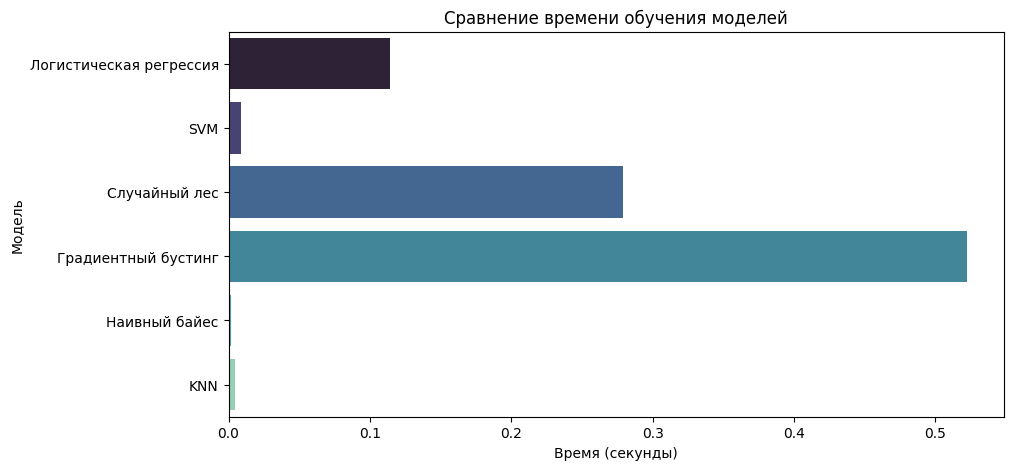


Визуализация результатов классификации (Матрица ошибок для лучшей модели)


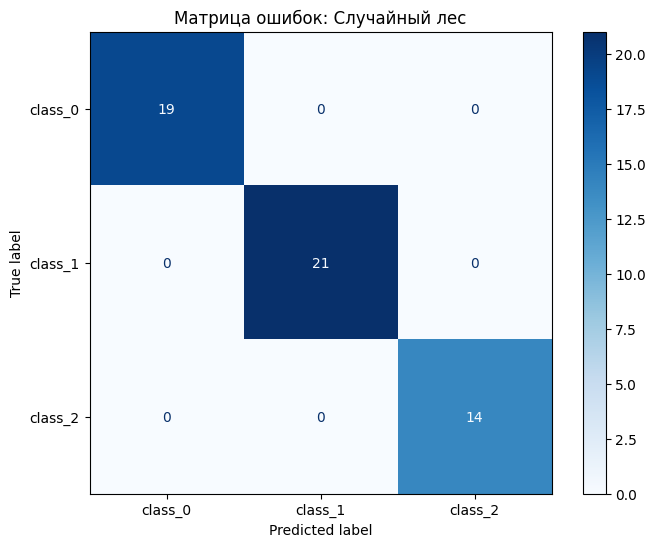


Влияние уменьшения размерности (PCA) на размер модели
Размер модели, обученной на полных данных: 1215 байт
Размер модели, обученной на данных после PCA: 943 байт
Уменьшение размерности признаков позволило сократить объем модели на 22.39%.


In [ ]:
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("\nОценка времени обучения моделей")
plt.figure(figsize=(10, 5))
# Используем данные из summary_df, который мы собрали на предыдущем шаге
sns.barplot(x="Время обуч. (с)", y="Модель", data=summary_df, palette="mako")
plt.title("Сравнение времени обучения моделей")
plt.xlabel("Время (секунды)")
plt.ylabel("Модель")
plt.show()

print("\nВизуализация результатов классификации (Матрица ошибок для лучшей модели)")
best_model_name = best_model['Модель']
best_model_instance = models[best_model_name]
best_model_instance.fit(X_train_scaled, y_train)
y_pred_best = best_model_instance.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=wine_data.target_names if 'wine_data' in locals() else None,
    cmap=plt.cm.Blues,
    ax=ax
)
disp.ax_.set_title(f"Матрица ошибок: {best_model_name}")
plt.show()


print("\nВлияние уменьшения размерности (PCA) на размер модели")


model_full = LogisticRegression().fit(X_train_scaled, y_train)
model_pca = LogisticRegression().fit(X_train_pca, y_train)


joblib.dump(model_full, 'model_full_temp.joblib')
joblib.dump(model_pca, 'model_pca_temp.joblib')


size_full = os.path.getsize('model_full_temp.joblib')
size_pca = os.path.getsize('model_pca_temp.joblib')

print(f"Размер модели, обученной на полных данных: {size_full} байт")
print(f"Размер модели, обученной на данных после PCA: {size_pca} байт")

if size_full > 0:
    reduction_percent = (1 - size_pca / size_full) * 100
    print(f"Уменьшение размерности признаков позволило сократить объем модели на {reduction_percent:.2f}%.")


os.remove('model_full_temp.joblib')
os.remove('model_pca_temp.joblib')

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
from scipy.stats import uniform, randint


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


df = pd.read_csv(url, names=columns, na_values=[' ?', '?'])

display(df.head())

print("\nИнформация о типах данных и пропусках:")
print(df.info())


df.dropna(inplace=True)


df = df.sample(n=3000, random_state=42).reset_index(drop=True)


df['income'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)


categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


X = df.drop('income', axis=1)
y = df['income']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nДанные предобработаны. Количество признаков после One-Hot Encoding: {X_train_scaled.shape[1]}")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Данные предобработаны. Количество признаков пос

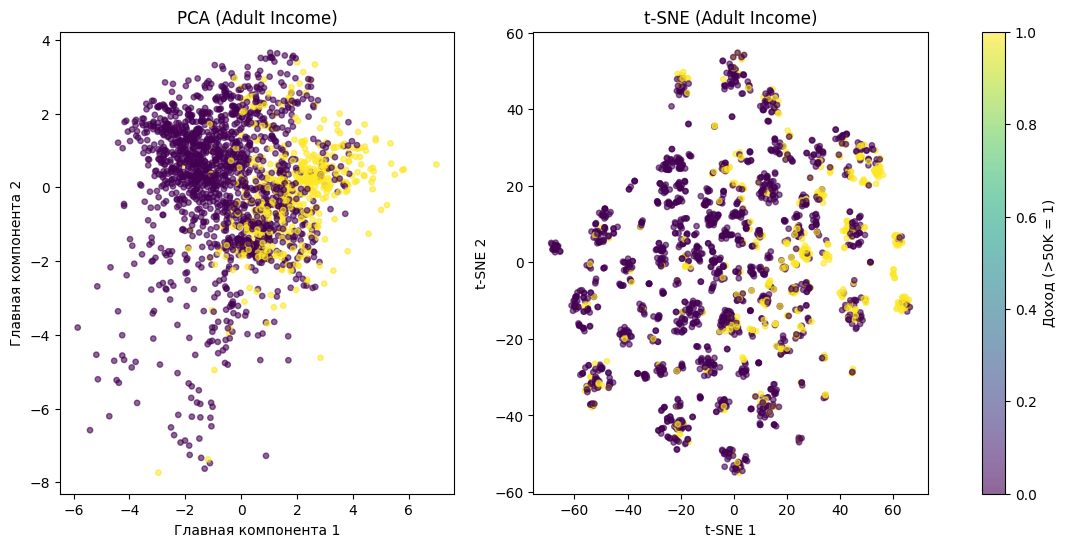

In [ ]:

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_scaled)



lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

scatter_pca = ax[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=15)
ax[0].set_title('PCA (Adult Income)')
ax[0].set_xlabel('Главная компонента 1')
ax[0].set_ylabel('Главная компонента 2')

scatter_tsne = ax[1].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=15)
ax[1].set_title('t-SNE (Adult Income)')
ax[1].set_xlabel('t-SNE 1')
ax[1].set_ylabel('t-SNE 2')

plt.colorbar(scatter_pca, ax=ax, label='Доход (>50K = 1)')
plt.show()

In [ ]:

models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, max_iter=2000, random_state=42),
    "Случайный лес": RandomForestClassifier(random_state=42),
    "Градиентный бустинг": GradientBoostingClassifier(random_state=42),
    "Наивный байес": GaussianNB(),
    "KNN": KNeighborsClassifier()
}


param_distributions = {
    "Случайный лес": {
        'n_estimators': randint(50, 300),
        'max_depth': randint(5, 30),
        'min_samples_split': randint(2, 15),
        'min_samples_leaf': randint(1, 10)
    }
}

results = []
n_bootstraps = 100

for name, model in models.items():
    print(f" Модель: {name} ")
    start_time = time.time()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc_full = accuracy_score(y_test, y_pred)
    train_time = time.time() - start_time

    print("Classification Report:")
    print(classification_report(y_test, y_pred))


    boot_scores = []
    for _ in range(n_bootstraps):
        X_boot, y_boot = resample(X_train_scaled, y_train)
        model.fit(X_boot, y_boot)
        boot_scores.append(accuracy_score(y_test, model.predict(X_test_scaled)))

    boot_mean = np.mean(boot_scores)
    boot_std = np.std(boot_scores)


    best_params = "Не применялся"
    best_rs_score = "Не применялся"
    if name in param_distributions:
        rs = RandomizedSearchCV(model, param_distributions[name], n_iter=15, cv=3, random_state=42, n_jobs=-1)
        rs.fit(X_train_scaled, y_train)
        best_params = rs.best_params_
        best_rs_score = rs.best_score_
        print(f"Лучшие параметры RS: {best_params}")


    model.fit(X_train_pca, y_train)
    acc_pca = accuracy_score(y_test, model.predict(X_test_pca))

    results.append({
        "Модель": name,
        "Точность (Все признаки)": acc_full,
        "Точность (PCA)": acc_pca,
        "Boot Ср. Точность": boot_mean,
        "Boot Ст. Отклон.": boot_std,
        "Время обуч. (с)": train_time,
        "Лучшие параметры RS": best_params,
        "Скор RS": best_rs_score
    })

 Модель: Логистическая регрессия 
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       678
           1       0.69      0.61      0.65       222

    accuracy                           0.84       900
   macro avg       0.78      0.76      0.77       900
weighted avg       0.83      0.84      0.83       900

 Модель: SVM 
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       678
           1       0.71      0.49      0.58       222

    accuracy                           0.82       900
   macro avg       0.78      0.71      0.73       900
weighted avg       0.81      0.82      0.81       900

 Модель: Случайный лес 
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       678
           1       0.70      0.62      0.66       222

    accuracy                           0.

,Модель,Точность (Все признаки),Точность (PCA),Boot Ср. Точность,Boot Ст. Отклон.,Время обуч. (с),Лучшие параметры RS,Скор RS
0,Логистическая регрессия,0.835556,0.818889,0.832211,0.005956,0.025982,Не применялся,Не применялся
1,SVM,0.824444,0.832222,0.823222,0.007178,1.104611,Не применялся,Не применялся
2,Случайный лес,0.840000,0.786667,0.832933,0.007965,0.402513,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.849048
3,Градиентный бустинг,0.850000,0.827778,0.849544,0.006167,0.568151,Не применялся,Не применялся
4,Наивный байес,0.324444,0.820000,0.400233,0.061437,0.007897,Не применялся,Не применялся
5,KNN,0.805556,0.806667,0.786833,0.009793,0.025099,Не применялся,Не применялся


1. Лучшая модель на полных признаках: Градиентный бустинг (Точность 85.00%).
2. Датасет Adult Income имеет сложную структуру после One-Hot Encoding (>80 признаков). Использование PCA (до 2 компонент) снизило точность лучшей модели до 82.78%, так как 2 компоненты не могут описать всю дисперсию таких разреженных данных.
3. Оценка бутстрэппингом показала высокую стабильность: средняя точность составила 84.95% (отклонение 0.0062).

Тепловая карта корреляций (Топ-15 признаков)


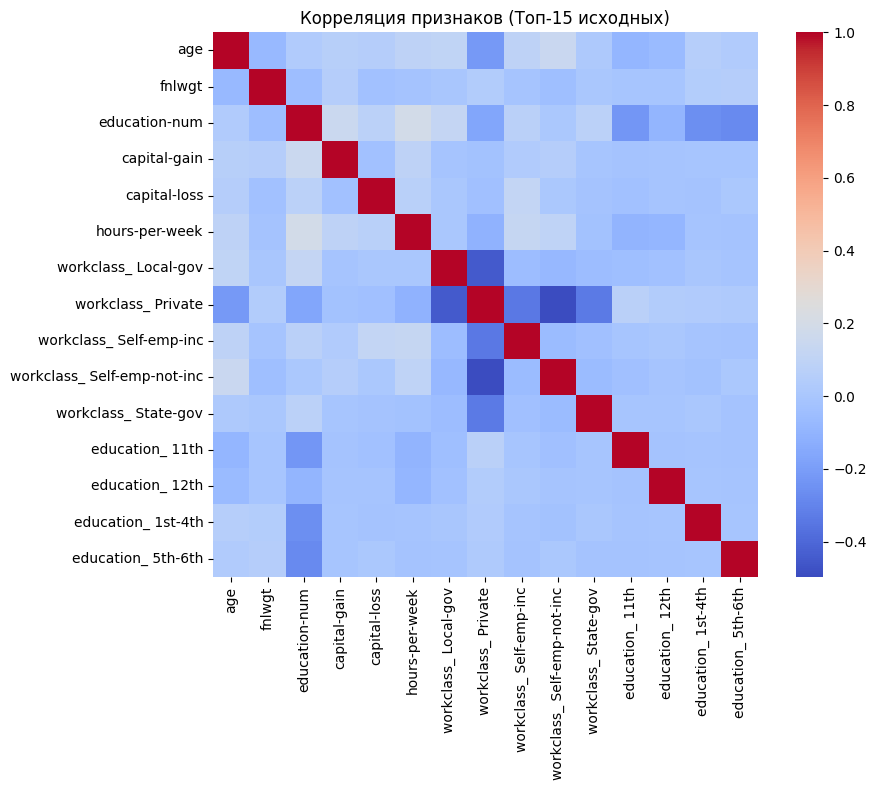


Сравнение времени обучения


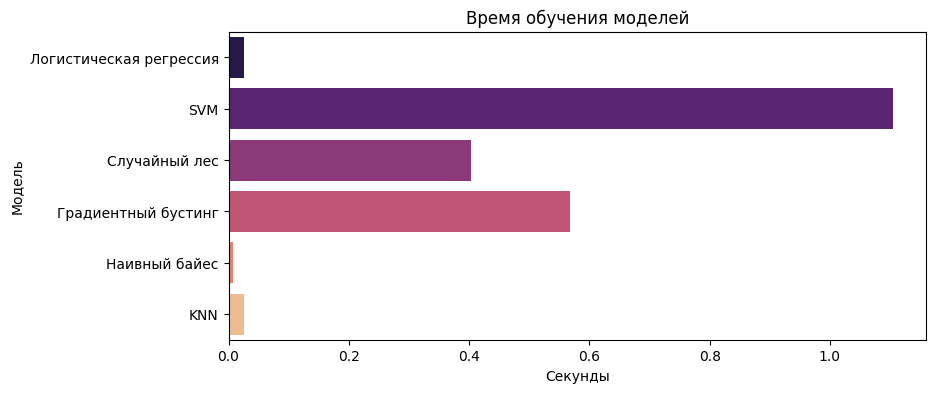


Матрица ошибок для Градиентный бустинг


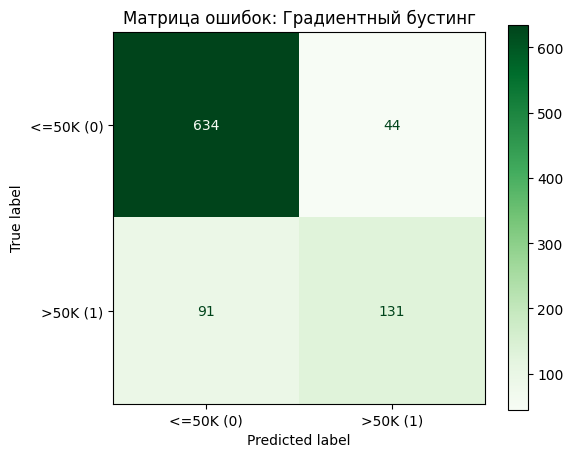


Влияние размерности на объем модели
Размер модели (все OHE признаки): 1567 байт
Размер модели (после PCA, 2 признака): 879 байт
Сжатие PCA уменьшило размер модели на 43.91%.


In [ ]:
summary_df = pd.DataFrame(results)
display(summary_df)

best_model_idx = summary_df["Точность (Все признаки)"].idxmax()
best_model_info = summary_df.loc[best_model_idx]
best_model_name = best_model_info['Модель']

print(f"1. Лучшая модель на полных признаках: {best_model_name} (Точность {best_model_info['Точность (Все признаки)']*100:.2f}%).")
print(f"2. Датасет Adult Income имеет сложную структуру после One-Hot Encoding (>80 признаков). Использование PCA (до 2 компонент) снизило точность лучшей модели до {best_model_info['Точность (PCA)']*100:.2f}%, так как 2 компоненты не могут описать всю дисперсию таких разреженных данных.")
print(f"3. Оценка бутстрэппингом показала высокую стабильность: средняя точность составила {best_model_info['Boot Ср. Точность']*100:.2f}% (отклонение {best_model_info['Boot Ст. Отклон.']:.4f}).")




print("\nТепловая карта корреляций (Топ-15 признаков)")
top_features = X.columns[:15]
plt.figure(figsize=(10, 8))
sns.heatmap(X[top_features].corr(), annot=False, cmap="coolwarm", cbar=True, square=True)
plt.title("Корреляция признаков (Топ-15 исходных)")
plt.tight_layout()
plt.show()


print("\nСравнение времени обучения")
plt.figure(figsize=(9, 4))
sns.barplot(x="Время обуч. (с)", y="Модель", data=summary_df, palette="magma")
plt.title("Время обучения моделей")
plt.xlabel("Секунды")
plt.show()


print(f"\nМатрица ошибок для {best_model_name}")
best_model_instance = models[best_model_name]
best_model_instance.fit(X_train_scaled, y_train)
y_pred_best = best_model_instance.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["<=50K (0)", ">50K (1)"],
    cmap=plt.cm.Greens, ax=ax
)
disp.ax_.set_title(f"Матрица ошибок: {best_model_name}")
plt.show()

print("\nВлияние размерности на объем модели")
model_full = LogisticRegression().fit(X_train_scaled, y_train)
model_pca = LogisticRegression().fit(X_train_pca, y_train)

joblib.dump(model_full, 'model_adult_full.joblib')
joblib.dump(model_pca, 'model_adult_pca.joblib')

size_full = os.path.getsize('model_adult_full.joblib')
size_pca = os.path.getsize('model_adult_pca.joblib')

print(f"Размер модели (все OHE признаки): {size_full} байт")
print(f"Размер модели (после PCA, 2 признака): {size_pca} байт")
if size_full > 0:
    print(f"Сжатие PCA уменьшило размер модели на {(1 - size_pca / size_full) * 100:.2f}%.")

os.remove('model_adult_full.joblib')
os.remove('model_adult_pca.joblib')